In [48]:
# 1. Data Preparation

import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# fetch dataset
covertype = fetch_ucirepo(id=31)

# data (as pandas dataframes)
X = covertype.data.features
y = covertype.data.targets

# metadata
print(covertype.metadata)

# variable information
print(covertype.variables)

# picking two cover types
NEG, POS = 1, 2 # 1 = Spruce/Fir, 2 = Lodgepole Pine

labels = y.values.ravel()
mask = np.isin(labels, [NEG,POS])

feat_names = list(X.columns) # keep the names before X becomes a plain array

X = X.values[mask].astype(float)
y = (labels[mask] == POS).astype(int)

print(f"\nClasses {NEG} vs {POS}: {X.shape[0]} rows, {X.shape[1]} features")
print(f"    y = 0 (type {NEG}): {(y == 0).sum()}     y = 1 (type {POS}): {(y == 1).sum()}")

N = 20_000
rng = np.random.default_rng(42)
keep = rng.choice(len(y), size = N, replace = False)
X, y = X[keep], y[keep]

# train-test split
perm = rng.permutation(N)
cut = int(0.8 *N)
train, test = perm[:cut], perm[cut:]
X_train, y_train = X[train], y[train],
X_test, y_test = X[test], y[test]

# standarizing
mu = X_train.mean(axis = 0) # mean
sd = X_train.std(axis = 0) # standard diviation
sd[sd == 0] = 1.0 # handling features with sd of 0

X_train = (X_train - mu) / sd
X_test = (X_test - mu) / sd

# sanity check
print("\nX_train:", X_train.shape, " X_test:", X_test.shape)
print("train class balance:", np.bincount(y_train), " test:", np.bincount(y_test))
print("train mean:", np.round(X_train.mean(axis = 0)[:5], 6)) # should be around 0
print("train std:", np.round(X_train.std(axis = 0)[:5], 6)) # should be around 1
print("test mean (not exactly 0 = correct):", np.round(X_test.mean(axis = 0)[:5], 4))

{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [ ]:
# 2.1 Perceptron

import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED = "#0B0B0b", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.labelcolor": INK, "axes.titlesize": 12, "axes.titlelocation": "left",
})

def step(z):
    """f(z) = 0 if z <= 0, 1 if z > 0"""
    return (z > 0).astype(int)

def predict(X, w, b):
    """y_hat = step(w^T x + b) for every row of X"""
    return step(X @ w + b)

def train_perceptron(X, y, eta = 1.0, epochs = 10):
    w = np.zeros(X.shape[1])
    b = 0.0
    for _ in range(epochs):                     # 5. repeat for several passes
        for i in range(len(y)):                 # 4. repeat for all training examples
            z = X[i] @ w + b
            y_hat = 1 if z > 0 else 0           # 1. make a prediction
            error = y[i] - y_hat                # 2. compare prediction with reality
            if error != 0:                      # 3. if wrong, change the weights
                w = w + eta * error * X[i]
                b = b + eta * error
    return w, b

def evaluate(y_true, y_pred):
    """metrics from the confusion matrix. positive class = 1 = Lodgepole Pine"""
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return dict(accuracy = accuracy, precision = precision, recall = recall, f1 = f1,
                tp = tp, tn = tn, fp = fp, fn = fn)

def print_report(name, m):
    print(name)
    for k in ("accuracy", "precision", "recall", "f1"):
        print(f"    {k:<10}{m[k]:.4f}")
    print("confusion matrix     pred Spruce/Fir     pred Lodgepole")
    print(f" true Spruce/Fir     {m['tn']:>15}       {m['fp']:>14}")
    print(f" true Lodgepole      {m['fn']:>15}       {m['tp']:>14}")

def _axis_label(name):
    unit = " (m)" if name == "Elevation" or "Distance" in name else ""
    return name.replace("_", " ") + unit

def plot_boundary(w, b, X, y, cols, title, n_points = 1500, seed = 0):
    i, j = cols
    xi = X[:, i] *sd[i] + mu[i] # z-score = original units
    xj = X[:, j] * sd[j] + mu[j]
    lo_i, hi_i = np.percentile(xi, [0.5, 99.5]) # trim the extreme 0.5% on each side
    lo_j, hi_j = np.percentile(xj, [0.5, 99.5])
    
    # compute z = w.x + b on a grid, the boundary is where z = 0
    gi, gj = np.meshgrid(np.linspace(lo_i, hi_i, 400), np.linspace(lo_j, hi_j, 400))
    grid_z = np.column_stack([(gi.ravel() - mu[i]) / sd[i], # standardize the grid the same way as the data
                            (gj.ravel() - mu[j]) / sd[j]])
    score = (grid_z @ w + b).reshape(gi.shape)

    fig, ax = plt.subplots(figsize = (10, 5.5))
    ax.contourf(gi, gj, score, levels = [-np.inf, 0, np.inf],
                colors = [BLUE, ORANGE], alpha = 0.12)
    ax.contour(gi, gj, score, levels = [0], colors = INK, linewidths = 2)
    
    # a random subset of points
    idx = np.random.default_rng(seed).choice(len(y), n_points, replace = False)
    for cls, color, label in [(0, BLUE, "Spruce/Fir (y = 0)"),
                            (1, ORANGE, "Lodgepole Pine (y = 1)")]:
        k = idx[y[idx] == cls]
        ax.scatter(xi[k], xj[k], s = 14, c = color, alpha = 0.7,
                edgecolors = "white", linewidths = 0.4, label = label)
    ax.plot([], [], color = INK, lw = 2, label = "decision boundary (z = 0)")

    ax.set_xlim(lo_i, hi_i)
    ax.set_ylim(lo_j, hi_j)
    ax.set_xlabel(_axis_label(feat_names[i]))
    ax.set_ylabel(_axis_label(feat_names[j]))
    ax.set_title(title, pad = 20)
    ax.text(0, 1.01, "shaded = predicted class: z <= 0 -> Spruce/Fir, z > 0 -> Lodgepole Pine",
            transform = ax.transAxes, fontsize = 9, color = MUTED, va = "bottom")
    ax.legend(loc = "upper left", bbox_to_anchor = (1.02, 1), frameon = False)
    plt.tight_layout()
    plt.show()

In [ ]:
# 2.2 Perceptron
# perceptron on all 54 features

w_perc, b_perc = train_perceptron(X_train, y_train, eta = 1.0)

y_pred_perc = predict(X_test, w_perc, b_perc)
perc_metrics = evaluate(y_test, y_pred_perc)

print_report("PERCEPTRON - all 54 features - TEST set", perc_metrics)
print(f"\nbaseline to beat (always guess Lodgepole Pine): {np.mean(y_test == 1):.4f}")

PERCEPTRON - all 54 features - TEST set
    accuracy  0.7060
    precision 0.7483
    recall    0.7279
    f1        0.7380
confusion matrix     pred Spruce/Fir     pred Lodgepole
 true Spruce/Fir                1168                  557
 true Lodgepole                  619                 1656

baseline to beat (always guess Lodgepole Pine): 0.5687


PERCEPTRON - 2 features ['Elevation', 'Horizontal_Distance_To_Hydrology'] - TEST set
    accuracy  0.7338
    precision 0.7410
    recall    0.8176
    f1        0.7774
confusion matrix     pred Spruce/Fir     pred Lodgepole
 true Spruce/Fir                1075                  650
 true Lodgepole                  415                 1860

weights (standardized units): {'Elevation': -2.42, 'Horizontal_Distance_To_Hydrology': 1.23}  bias: 1.0


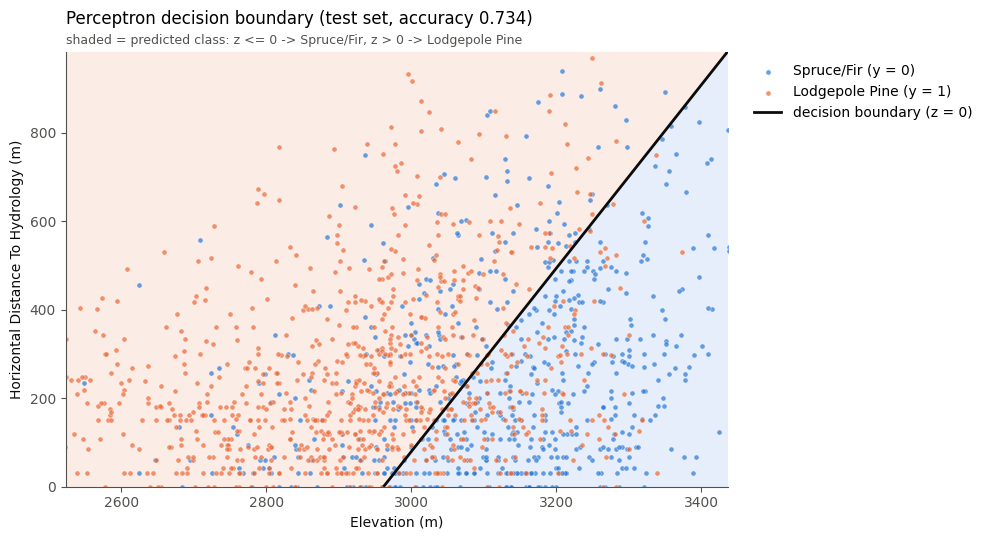

In [ ]:
# 2.3 Perceptron
# creating decision boundary with the two features

FEATS = ["Elevation", "Horizontal_Distance_To_Hydrology"]
cols = [feat_names.index(f) for f in FEATS]

w_perc2, b_perc2 = train_perceptron(X_train[:, cols], y_train, eta = 1.0)
perc2_metrics = evaluate(y_test, predict(X_test[:, cols], w_perc2, b_perc2))
print_report(f"PERCEPTRON - 2 features {FEATS} - TEST set", perc2_metrics)
print("\nweights (standardized units):",
    {f: round(float(v), 2) for f, v in zip(FEATS, w_perc2)}, " bias:", b_perc2)

plot_boundary(w_perc2, b_perc2, X_test, y_test, cols,
            f"Perceptron decision boundary (test set, accuracy "
            f"{perc2_metrics['accuracy']:.3f})")

In [ ]:
# 3.1 Logistic Regression

def sigmoid(z):
    "sigma(z) = 1 / (1 + e^(-z)), maps (-inf, +inf) -> (0, 1)"
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def bce_loss(y, y_hat):
    y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(y_hat) + (1 - y) *  np.log(1 - y_hat))

def predict_prob(X, w, b):
    return sigmoid(X @ w + b)

def predict_LR(X, w, b):
    #turning probability into a class: 1 if P(y = 1|x) > 0.5, else 0
    return (predict_prob(X, w, b) > 0.5).astype(int)

def train_logistic_regression(X, y, eta = 0.001):
    w = np.zeros(X.shape[1])
    b = 0.0
    for i in range(len(y)):
        y_hat = sigmoid(X[i] @ w + b)           # 1. prediction
        y_hat = sigmoid(X[i] @ w + b)           # 2. BCE loss
        grad = y_hat - y[i]                     # 3. gradient
        w = w - eta * grad * X[i]               # 4. update weights
        b = b - eta * grad
    return w, b

In [ ]:
# 3.2 Logistic Regression
# logistic regression on all 54 features

J_before = bce_loss(y_train, predict_prob(X_train, np.zeros(X_train.shape[1]), 0.0))
w_lr, b_lr = train_logistic_regression(X_train, y_train, eta = 0.001)
J_after = bce_loss(y_train, predict_prob(X_train, w_lr, b_lr))
print(f"training BCE (J): {J_before:.4f} before training -> {J_after:.4f} after\n")

p_test_lr = predict_prob(X_test, w_lr, b_lr)
y_pred_lr = (p_test_lr > 0.5).astype(int)
lr_metrics = evaluate(y_test, y_pred_lr)

print_report("LOGISTIC REGRESSION - all 54 features - TEST set", lr_metrics)
print(f"\nbaseline to beat (always guess Lodgepole Pine): {np.mean(y_test == 1):.4f}")

training BCE (J): 0.6931 before training -> 0.4923 after

LOGISTIC REGRESSION - all 54 features - TEST set
    accuracy  0.7642
    precision 0.7757
    recall    0.8237
    f1        0.7990
confusion matrix     pred Spruce/Fir     pred Lodgepole
 true Spruce/Fir                1183                  542
 true Lodgepole                  401                 1874

baseline to beat (always guess Lodgepole Pine): 0.5687


LOGISTIC REGRESSION - 2 features ['Elevation', 'Horizontal_Distance_To_Hydrology'] - TEST set
    accuracy  0.7392
    precision 0.7612
    recall    0.7890
    f1        0.7749
confusion matrix     pred Spruce/Fir     pred Lodgepole
 true Spruce/Fir                1162                  563
 true Lodgepole                  480                 1795

weights (standardized units): {'Elevation': -1.27, 'Horizontal_Distance_To_Hydrology': 0.36}  bias: 0.39


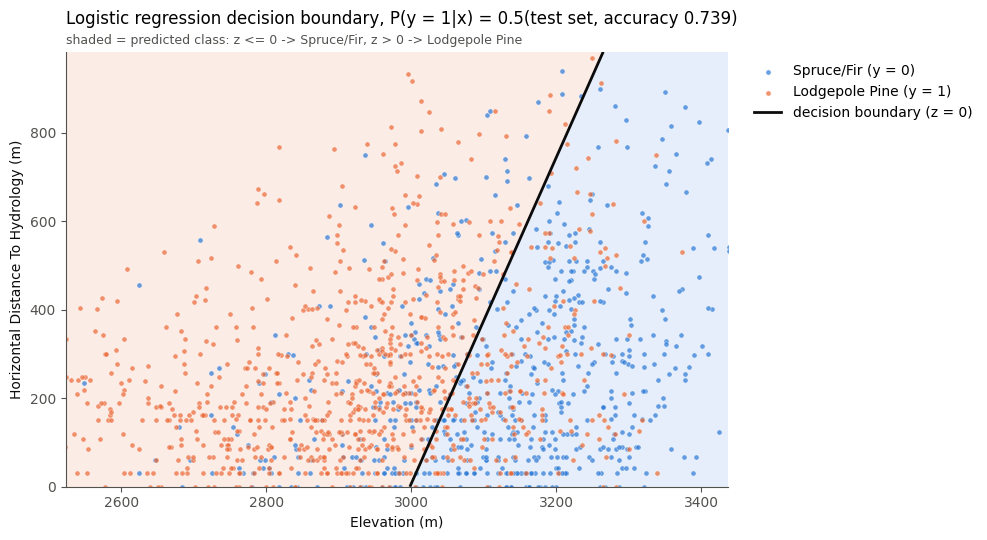

In [ ]:
# 3.3 Logistic Regression
# decision boundary with the same two features

w_lr2, b_lr2 = train_logistic_regression(X_train[:, cols], y_train, eta = 0.001)
lr2_metrics = evaluate(y_test, predict_LR(X_test[:, cols], w_lr2, b_lr2))
print_report(f"LOGISTIC REGRESSION - 2 features {FEATS} - TEST set", lr2_metrics)
print("\nweights (standardized units):",
    {f: round(float(v), 2) for f, v in zip(FEATS, w_lr2)}, " bias:", round(float(b_lr2), 2))

plot_boundary(w_lr2, b_lr2, X_test, y_test, cols,
            f"Logistic regression decision boundary, P(y = 1|x) = 0.5"
            f"(test set, accuracy {lr2_metrics['accuracy']:.3f})")

In [ ]:
# 4.1 Binary Cross-Entropy (BCE)
# average BCE over the N test examples

test_bce = bce_loss(y_test, p_test_lr)
print(f"BCE loss on the test set ({len(y_test)} examples): {test_bce:.4f}\n")

# BCE for each test example son its own
p = np.clip(p_test_lr, 1e-15, 1 - 1e-15)
loss_each = -(y_test * np.log(p) + (1 - y_test) * np.log(1 - p))

# "two doors": the true label decides which term counts
is1, is0 = (y_test == 1), (y_test == 0)
print("average loss by true class:")
print(f" y = 1 (Lodgepole Pine), L = -log(y_hat):   {loss_each[is1].mean():.4f}     ({is1.sum()} examples)")
print(f" y = 0 (Spruce/Fir), L = -log(1 - y_hat):   {loss_each[is0].mean():.4f}     ({is0.sum()} examples)")

# "confidently wrong = very large penalty": loss >= 2.30 means the true class
# got 10% probability or less (the 0.10 -> 2.30 row in the slides' tables)
conf_wrong = loss_each >= -np.log(0.10)
print(f"\nconfidently wrong (true class got <= 10% probability): {conf_wrong.sum()} examples"
    f" = {conf_wrong.mean():.1%} of the test set, but {loss_each[conf_wrong].sum() / loss_each.sum():.1%}"
    f" of the total loss")

BCE loss on the test set (4000 examples): 0.4993

average loss by true class:
 y = 1 (Lodgepole Pine), L = -log(y_hat):   0.4228     (2275 examples)
 y = 0 (Spruce/Fir), L = -log(1 - y_hat):   0.6001     (1725 examples)

confidently wrong (true class got <= 10% probability): 33 examples = 0.8% of the test set, but 4.4% of the total loss


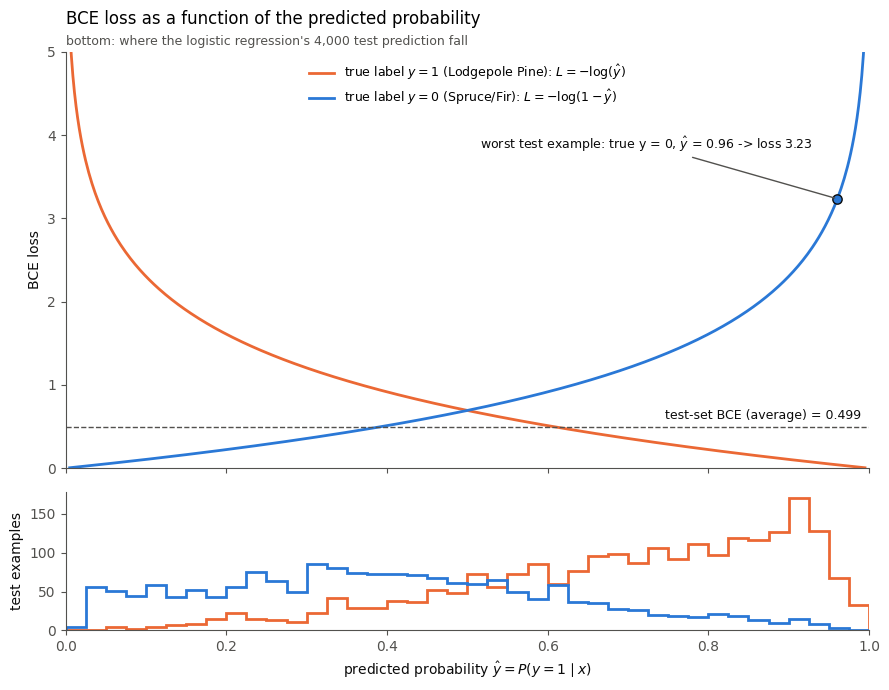

In [ ]:
# 4.2 Binary Cross-Entropy (BCE)
# BCE loss as a function of the predicted prob

from matplotlib.patches import ArrowStyle


y_hat = np.linspace(0.005, 0.995, 500) # stop short of 0 and 1: log(0) = -infinity

# top: the loss curves
# bottom: where the model's 4,000 test prediction landed
fig, (ax, axh) = plt.subplots(2, 1, figsize = (9, 7), sharex = True,
                            gridspec_kw = {"height_ratios": [3, 1]})
ax.plot(y_hat, -np.log(y_hat), color = ORANGE, lw = 2,
        label = r"true label $y = 1$ (Lodgepole Pine): $L = -\log(\hat{y})$")
ax.plot(y_hat, -np.log(1 - y_hat), color = BLUE, lw = 2,
        label = r"true label $y = 0$ (Spruce/Fir): $L = -\log(1 - \hat{y})$")

# the test set BCE: every test example sits on the curve for its true label, and this is the average of all their losses
ax.axhline(test_bce, color = MUTED, lw = 1, ls = "--")
ax.text(0.99, test_bce + 0.06, f"test-set BCE (average) = {test_bce:.3f}",
        ha = "right", va = "bottom", fontsize = 9, color  = INK)

# a coin flip costs the same either way
k = np.argmax(loss_each)
ax.scatter([p_test_lr[k]], [loss_each[k]], s = 45, color = BLUE, edgecolors = INK, zorder = 3)
ax.annotate(f"worst test example: true y = {y_test[k]}, "
            + r"$\hat{y}$" + f" = {p_test_lr[k]:.2f} -> loss {loss_each[k]:.2f}",
            xy = (p_test_lr[k], loss_each[k]), xytext = (p_test_lr[k] - 0.03, loss_each[k] + 0.6),
            ha = "right", fontsize = 9, color = INK,
            arrowprops = dict(arrowstyle = "-", color = MUTED, lw = 1))

ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
ax.set_ylabel("BCE loss")
ax.set_title("BCE loss as a function of the predicted probability", pad = 20)
ax.text(0, 1.01, "bottom: where the logistic regression's 4,000 test prediction fall",
        transform = ax.transAxes, fontsize = 9, color = MUTED, va = "bottom")
ax.legend(loc = "upper center", frameon = False, fontsize = 9)

bins = np.linspace(0, 1, 41)
axh.hist(p_test_lr[is1], bins = bins, histtype = "step", lw = 2, color = ORANGE)
axh.hist(p_test_lr[is0], bins = bins, histtype = "step", lw = 2, color = BLUE)
axh.set_ylabel("test examples")
axh.set_xlabel(r"predicted probability $\hat{y} = P(y = 1 \mid x)$")
plt.tight_layout()
plt.show()
